In [77]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.under_sampling import RandomUnderSampler
# from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, classification_report

In [2]:
df_reviews = pd.read_csv("IMDB Dataset.csv", engine = "python", on_bad_lines = "skip")

In [3]:
df_positive = df_reviews[df_reviews['sentiment'] == 'positive'][:9000]
df_negative = df_reviews[df_reviews['sentiment'] == 'negative'][:1000]

In [4]:
df_reviews_imb = pd.concat([df_positive, df_negative])

<Axes: xlabel='sentiment'>

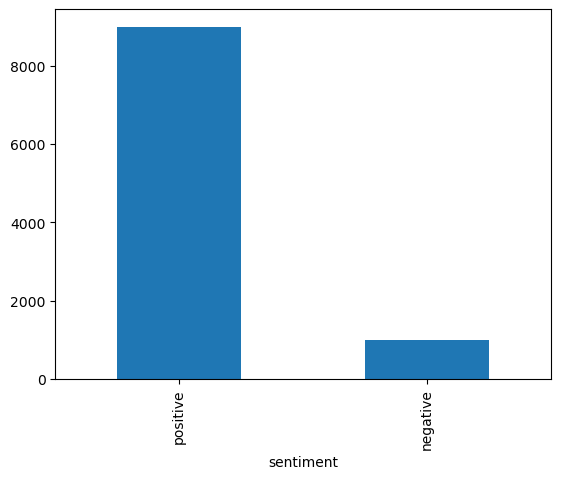

In [5]:
df_reviews_imb.value_counts('sentiment').plot(kind = 'bar')

In [6]:
# length_negative = len(df_reviews_imb[df_reviews_imb['sentiment'] == 'negative'])
# df_reviews_positive = df_reviews_imb[df_reviews_imb['sentiment'] == 'positive'].sample(n = length_negative)
# df_reviews_negative = df_reviews[df_reviews['sentiment'] == 'negative'][:1000]

In [7]:
# df_reviews_bal = pd.concat([df_reviews_positive, df_reviews_negative])
# df_reviews_bal = df_reviews_bal.reset_index(drop = True)

In [8]:
# Alternate method:

In [9]:
rus = RandomUnderSampler(random_state = 0)
df_reviews_bal, df_reviews_bal['sentiment'] = rus.fit_resample(df_reviews_imb[['review']], df_reviews_imb['sentiment'])

# First argument should be a data frame, while second argument should be a series.
# Gives two outputs: Review (Data frame) and Sentiment (Series) (separately)
# We create a new data frame (df_reviews_bal) and for it, a new series ( df_reviews_bal['sentiment'])

In [20]:
df_reviews_bal = df_reviews_bal.reset_index(drop = True)

In [15]:
train, test = train_test_split(df_reviews_bal, test_size = 0.33)

In [12]:
train_x, train_y = train['review'], train['sentiment']
test_x, test_y = test['review'], test['sentiment']

In [30]:
tf_idf = TfidfVectorizer(stop_words = 'english')
train_x_vector = tf_idf.fit_transform(train_x)

In [29]:
test_x_vector = tf_idf.transform(test_x)
# No need to fit since we already have best parameters in tf_idf (by line [26])

In [34]:
# Support Vector Machine (SVM)
svc = SVC(kernel = 'linear')
svc.fit(train_x_vector, train_y)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [41]:
# svc.predict(tf_idf.transform(['A good movie']))
# svc.predict(tf_idf.transform(['A boring movie']))
# svc.predict(tf_idf.transform(['It was okay I guess']))

# Conclusion: SVM working as intended.

In [43]:
# Decision Trees
dtc = DecisionTreeClassifier()
dtc.fit(train_x_vector, train_y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [59]:
# Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(train_x_vector.toarray(), train_y)

,priors,None
,var_smoothing,1e-09


In [64]:
# Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(train_x_vector, train_y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [66]:
# Using confusion matrix to determine relevancy of trained models.

confusion_matrix(test_y, svc.predict(test_x_vector), labels = ['positive', 'negative'])
# 294 True Positive, 48 False Negatives, 64 False Positives, 254 True Negatives


array([[294,  48],
       [ 64, 254]])

In [69]:
# Accuracy for all models.
# Mean Accuracy: When TP and TN are more important than FP and FN.

print(f"Support Vector Machine: {svc.score(test_x_vector, test_y)}")
print(f"Decision Tree: {dtc.score(test_x_vector, test_y)}")
print(f"Gaussian Naive Bayes: {gnb.score(test_x_vector.toarray(), test_y)}")
print(f"Logistic Regression: {log_reg.score(test_x_vector, test_y)}")

Support Vector Machine: 0.8303030303030303
Decision Tree: 0.6454545454545455
Gaussian Naive Bayes: 0.6106060606060606
Logistic Regression: 0.8121212121212121


In [71]:
# F1 Score: When FP and FN are crucial. It also takes into account the data distribution.

f1_score(test_y, svc.predict(test_x_vector), labels = ['positive', 'negative'], average = None)

array([0.84      , 0.81935484])

In [76]:
print(classification_report(test_y, svc.predict(test_x_vector), labels = ['positive', 'negative']))

              precision    recall  f1-score   support

    positive       0.82      0.86      0.84       342
    negative       0.84      0.80      0.82       318

    accuracy                           0.83       660
   macro avg       0.83      0.83      0.83       660
weighted avg       0.83      0.83      0.83       660



In [79]:
# Tuning the model.

parameters = {'C': [1, 4, 8, 16, 32], 'kernel': ['linear', 'rbf']}

svc = SVC()
svc_grid = GridSearchCV(svc, parameters, cv = 5)
svc_grid.fit(train_x_vector, train_y)

,estimator,SVC()
,param_grid,"{'C': [1, 4, ...], 'kernel': ['linear', 'rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,4


In [80]:
svc_grid.best_params_

{'C': 4, 'kernel': 'rbf'}

In [82]:
svc_grid.best_estimator_

,C,4
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False
